In [1]:
import pandas as pd 
housing = pd.read_csv("BHP.csv")
housing.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


<div style="
    background: linear-gradient(90deg, #1e3c72, #2a5298);
    padding: 18px;
    border-radius: 12px;
    text-align: center;
    color: white;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.2);
    font-family: Arial, sans-serif;
">

<h4>Basic Inspection of Dataset</h4>

<p style="font-size:16px;">
Understanding the structure, data types, missing values, and overall characteristics of each feature before preprocessing.
</p>

</div>

In [2]:
housing['area_type'].unique()

<StringArray>
['Super built-up  Area', 'Plot  Area', 'Built-up  Area', 'Carpet  Area']
Length: 4, dtype: str

In [3]:
housing['availability'].unique()

<StringArray>
[              '19-Dec',        'Ready To Move',               '18-May',
               '18-Feb',               '18-Nov',               '20-Dec',
               '17-Oct',               '21-Dec',               '19-Sep',
               '20-Sep',               '18-Mar',               '20-Feb',
               '18-Apr',               '20-Aug',               '18-Oct',
               '19-Mar',               '17-Sep',               '18-Dec',
               '17-Aug',               '19-Apr',               '18-Jun',
               '22-Dec',               '22-Jan',               '18-Aug',
               '19-Jan',               '17-Jul',               '18-Jul',
               '21-Jun',               '20-May',               '19-Aug',
               '18-Sep',               '17-May',               '17-Jun',
               '21-May',               '18-Jan',               '20-Mar',
               '17-Dec',               '16-Mar',               '19-Jun',
               '22-Jun',             

In [4]:
housing['location'].unique()

<StringArray>
[                       'Electronic City Phase II',
                                'Chikka Tirupathi',
                                     'Uttarahalli',
                              'Lingadheeranahalli',
                                        'Kothanur',
                                      'Whitefield',
                                'Old Airport Road',
                                    'Rajaji Nagar',
                                    'Marathahalli',
                                    'Gandhi Bazar',
 ...
                               'Masjid e Alkareem',
                                   'Sindhi Colony',
                             'Kanakapur main road',
                       'Prasanna layout Herohalli',
                               'Sarvobhogam Nagar',
                                  'Pattegarhpalya',
                                     'Tilak Nagar',
 '12th cross srinivas nagar banshankari 3rd stage',
                               'Havanur exten

In [5]:
housing['size'].unique()

<StringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',      '4 BHK',  '6 Bedroom',
  '3 Bedroom',      '1 BHK',       '1 RK',  '1 Bedroom',  '8 Bedroom',
  '2 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',          nan,  '9 Bedroom',
     '27 BHK', '10 Bedroom', '11 Bedroom',     '10 BHK',     '19 BHK',
     '16 BHK', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
     '13 BHK', '18 Bedroom']
Length: 32, dtype: str

In [6]:
housing['society'].unique()

<StringArray>
['Coomee ', 'Theanmp',       nan, 'Soiewre', 'DuenaTa', 'Jaades ', 'Brway G',
 'Prrry M', 'Shncyes', 'Skityer',
 ...
 'SRanail', 'Anncyar', 'JJr 2e ', 'Saentpa', 'Emtat H', 'Maa 5a ', 'AeisePV',
 'SJovest', 'ThhtsV ', 'RSntsAp']
Length: 2689, dtype: str

In [7]:
housing.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

<div style="
    background: linear-gradient(90deg, #134E5E, #71B280);
    padding: 18px;
    border-radius: 12px;
    text-align: center;
    color: white;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.2);
    font-family: Arial, sans-serif;
">

<h4>Data Cleaning & Preprocessing</h4>

<p style="font-size:16px;">
Transforming raw housing data by handling missing values, correcting inconsistencies, and preparing features for reliable analysis.
</p>

</div>

In [8]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [9]:
housing.groupby("location")["society"].nunique().sort_values(ascending=False)

location
Whitefield              133
Sarjapur  Road           91
Electronic City          52
Yelahanka                44
Marathahalli             39
                       ... 
 south                    0
 ittamadu                 0
 Sector 1 HSR Layout      0
 Mysore Highway           0
 Basavangudi              0
Name: society, Length: 1305, dtype: int64

In [10]:
housing.groupby("location")["society"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
)

location
 Anekal                     NaN
 Banaswadi              Krntsee
 Basavangudi                NaN
 Bhoganhalli            Rosha I
 Devarabeesana Halli    Sorisa 
                         ...   
t.c palya                   NaN
tc.palya                    NaN
vinayakanagar               NaN
white field,kadugodi        NaN
whitefiled                  NaN
Name: society, Length: 1305, dtype: str

In [11]:
housing["society"] = housing.groupby("location")["society"].transform(
    lambda x: x.fillna(
        x.mode().iloc[0] if not x.mode().empty else "Unknown"
    )
)

In [12]:
housing["society"].isnull().sum()

np.int64(1)

In [13]:
housing.isnull().sum()

area_type         0
availability      0
location          1
size             16
society           1
total_sqft        0
bath             73
balcony         609
price             0
dtype: int64

In [14]:
housing["bhk"] = housing["size"].str.extract(r'(\d+)')

In [15]:
housing["bhk"] = housing["bhk"].astype(float)

In [16]:
housing["bhk"].isnull().sum()

np.int64(16)

In [17]:
housing["bhk"] = housing.groupby("location")["bhk"].transform(
    lambda x: x.fillna(x.median())
)

In [18]:
housing.drop("size", axis=1, inplace=True)

In [19]:
housing["bath"] = housing.groupby("bhk")["bath"].transform(
    lambda x: x.fillna(x.median())
)

In [20]:
housing["bath"].isnull().sum()

np.int64(2)

In [21]:
housing[housing["balcony"].isnull()]["bhk"].value_counts()

bhk
3.0     213
4.0     179
5.0      57
2.0      51
6.0      29
8.0      21
9.0      20
7.0      15
10.0     11
1.0       8
19.0      1
16.0      1
11.0      1
18.0      1
Name: count, dtype: int64

In [22]:
housing.loc[
    (housing["bhk"] == 1) & (housing["balcony"].isnull()),
    "balcony"
] = 0

In [23]:
housing["balcony"] = housing.groupby("bhk")["balcony"].transform(
    lambda x: x.fillna(x.median())
)

In [24]:
housing["balcony"].isnull().sum()

np.int64(5)

In [25]:
housing.isnull().sum()

area_type       0
availability    0
location        1
society         1
total_sqft      0
bath            2
balcony         5
price           0
bhk             2
dtype: int64

In [26]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   society       13319 non-null  str    
 4   total_sqft    13320 non-null  str    
 5   bath          13318 non-null  float64
 6   balcony       13315 non-null  float64
 7   price         13320 non-null  float64
 8   bhk           13318 non-null  float64
dtypes: float64(4), str(5)
memory usage: 936.7 KB


In [27]:
housing['total_sqft'].unique()

<StringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
 ...
        '3124',        '9200',         '613',         '250',        '2395',
 '1020 - 1130',        '2758', '1133 - 1384',         '774',        '4689']
Length: 2117, dtype: str

In [28]:
housing.dropna(inplace=True)

In [29]:
housing['total_sqft'] = pd.to_numeric(
    housing['total_sqft'],
    errors = 'coerce'
)

<div style="
    background: linear-gradient(90deg, #42275a, #734b6d);
    padding: 18px;
    border-radius: 12px;
    text-align: center;
    color: white;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.2);
    font-family: Arial, sans-serif;
">

<h4>Exploratory Data Analysis (EDA)</h4>

<p style="font-size:16px;">
Analyzing patterns, distributions, correlations, and hidden insights within the housing dataset to understand feature behavior and relationships.
</p>

</div>

In [30]:
housing.head()

,area_type,availability,location,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,Aklia R,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,Somumys,1200.0,2.0,1.0,51.00,2.0


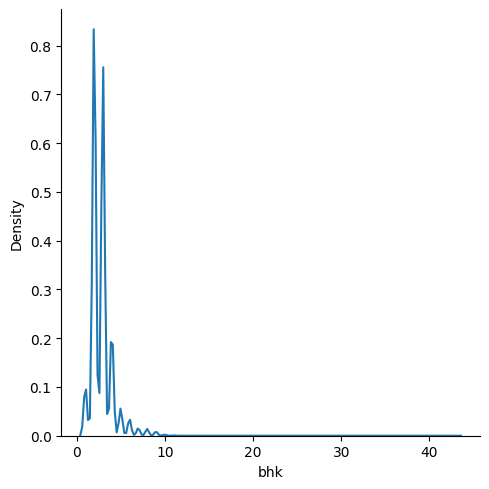

In [31]:
import seaborn as sns 
sns.displot( data = housing , x = 'bhk', kind = 'kde')

<h5><strong> Key Takeaways : </strong></h5>

<ul>
  <li>The x-axis extends all the way to 40+ BHK with a very long, flat right tail. This strongly highlights the presence of extreme outliers or potential data entry errors in the dataset that will need to be addressed during your preprocessing phase.</li>
  <li>The resulting distribution curve heavily peaks between 2 and 3 BHK, indicating that the vast majority of listed properties in this dataset fall into these standard configurations.</li>
</ul>  



<Axes: xlabel='count', ylabel='location'>

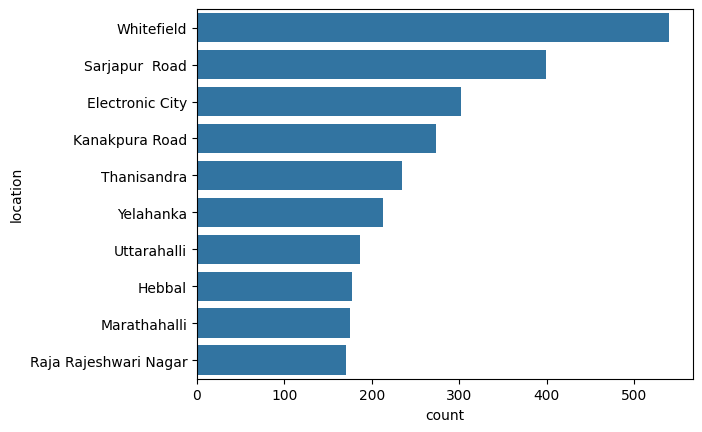

In [33]:
import seaborn as sns

sns.countplot(
    y=housing["location"],
    order=housing["location"].value_counts().head(10).index
)

In [34]:
top_locations = housing["location"].value_counts().head(10).index

top_data = housing[
    housing["location"].isin(top_locations)
]

<Axes: xlabel='count', ylabel='society'>

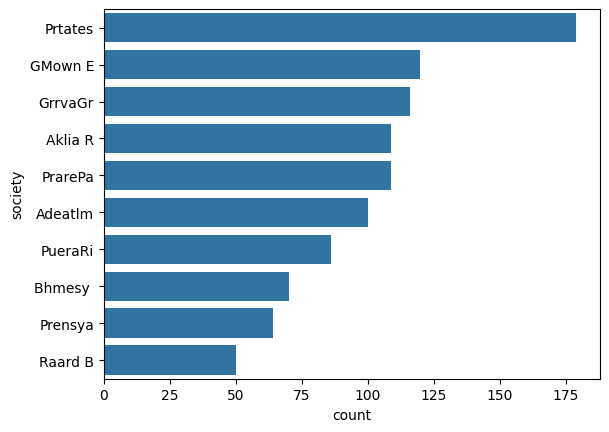

In [35]:
sns.countplot(
    y=top_data["society"],
    order=top_data["society"].value_counts().head(10).index
)

<h4><strong>Key Takeaway : </strong></h4>

<ul>
  <li>A small number of societies account for a large share of housing listings, indicating concentration of residential activity in specific communities.</li>
  <li>High-frequency societies may indicate areas with strong residential demand and active property transactions.</li>
  <li>Same sqft ≠ Same price always</li>
  <li>Premium society → better amenities → higher price</li>
<ul>  

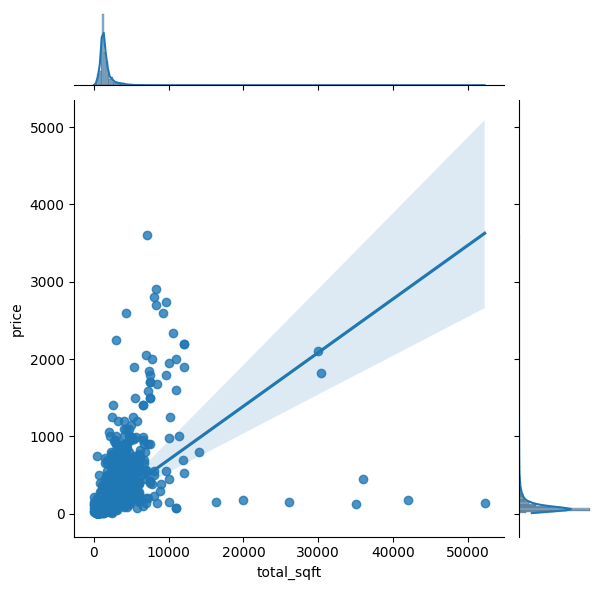

In [36]:
sns.jointplot(
    data=housing,
    x="total_sqft",
    y="price",
    kind="reg"
)

<h4><strong>Key takeaways : </strong></h4>

<ul>
  <li>Positive relationship exists between size and price.Higher sqft → Higher price</li>
  <li>Price variability increases for larger properties, indicating that additional premium factors influence valuation at higher property sizes.</li>
  <li>Extreme high-value observations suggest the presence of potential outliers that may require treatment before model training.</li>
</ul>  

<Axes: xlabel='bhk', ylabel='price'>

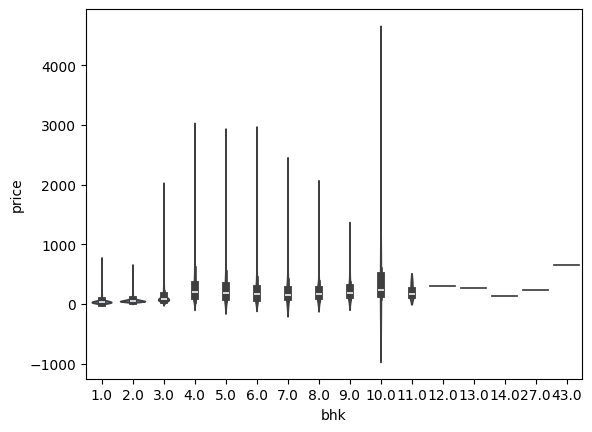

In [37]:
sns.violinplot(
    data=housing,
    x="bhk",
    y="price"
)

<h4><strong>Key takeaways</h4></strong>
<ul>
  <li>Property prices generally increase as the number of bedrooms increases, indicating that larger residential units tend to have higher market value.</li>
  <li>Larger properties exhibit wider price distributions, indicating increased valuation variation in premium housing segments.</li>
  <li>The housing dataset is primarily concentrated around mid-sized residential properties, particularly within the 2–4 BHK range.</li>
</ul>  

<Axes: >

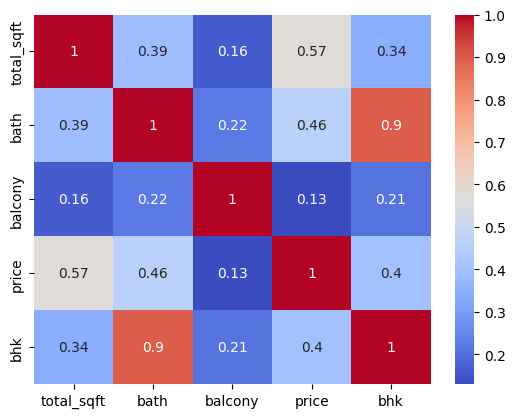

In [38]:
corr = housing.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

<div style="
background: linear-gradient(90deg, #1D4350, #A43931);
padding:18px;
border-radius:12px;
text-align:center;
color:white;
font-family:Arial;
">

<h4>Outlier Detection and Treatment using IQR Method</h4>

<p>
Identifying extreme observations in numerical features and applying the Interquartile Range (IQR) technique to detect and handle outliers before predictive modeling.
</p>

</div>

In [39]:
num_cols = housing.select_dtypes(include=["int64","float64"]).columns

num_cols

Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk'], dtype='str')

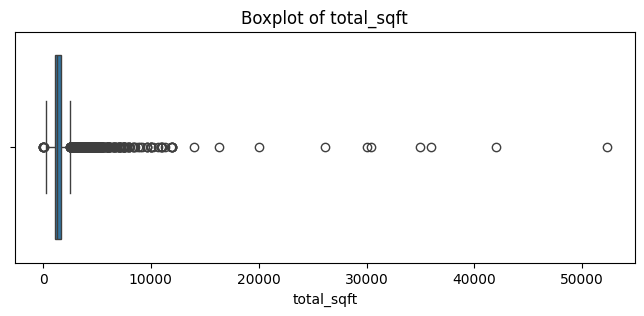

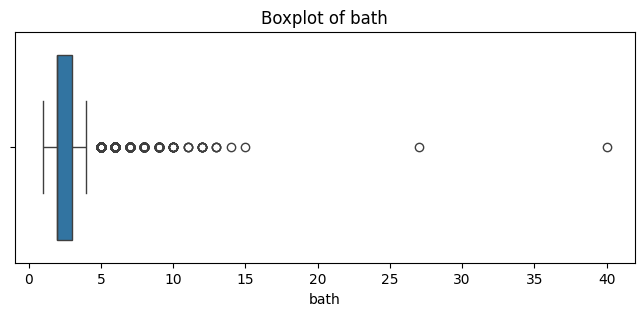

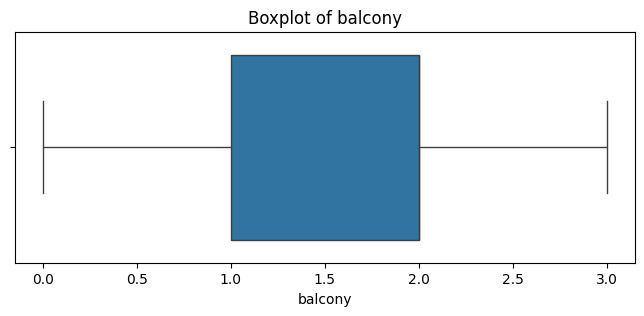

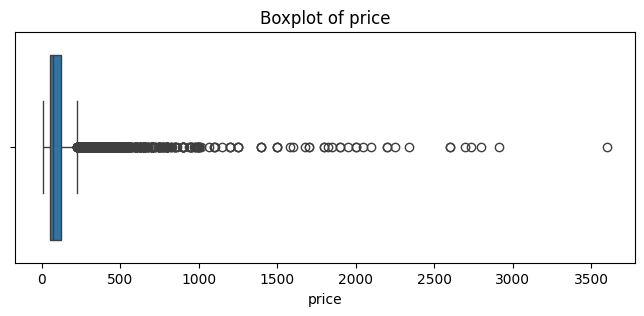

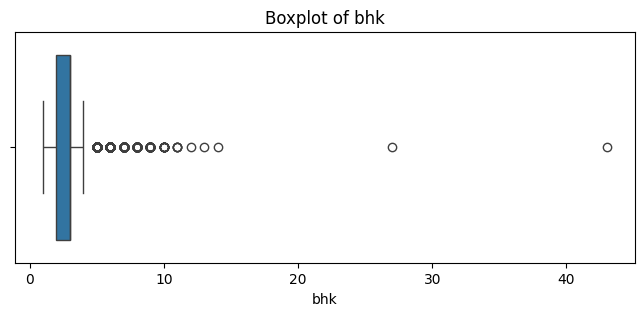

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=housing[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

In [41]:
def remove_outliers(df, col):
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]
    
    return df

In [42]:
housing = remove_outliers(housing, "price")
print("After price:", housing.shape)

housing = remove_outliers(housing, "total_sqft")
print("After sqft:", housing.shape)

housing = remove_outliers(housing, "bath")
print("After bath:", housing.shape)

After price: (12041, 9)
After sqft: (11153, 9)
After bath: (10821, 9)


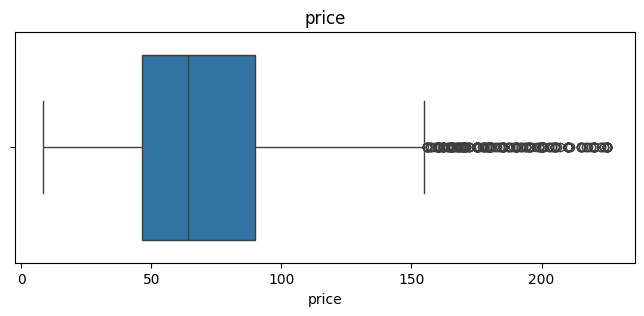

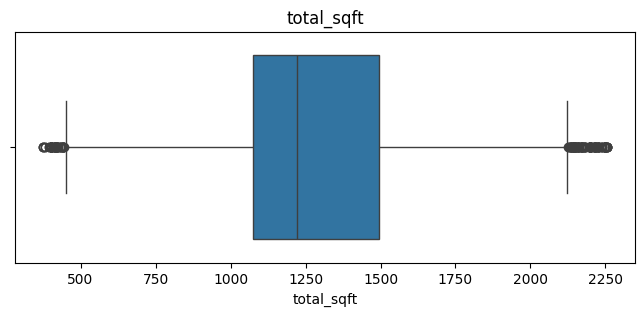

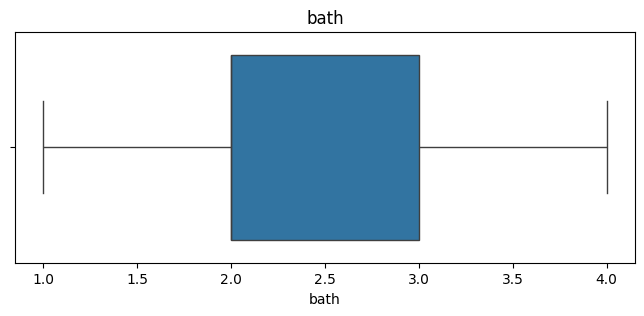

In [43]:
for col in ["price", "total_sqft", "bath"]:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=housing[col])
    
    plt.title(col)
    
    plt.show()

<div style="
background:#1E293B;
padding:15px;
border-radius:10px;
color:white;
font-family:Arial;
">

<h4>Key Observations After IQR Outlier Treatment</h4>

<ul>
<li>Outlier detection was performed using the Interquartile Range (IQR) statistical method.</li>
<li>Outlier treatment was selectively applied to <b>price</b>, <b>total_sqft</b>, and <b>bath</b> as these features showed significant extreme observations.</li>
<li>The dataset size reduced gradually after each treatment step, indicating successful removal of abnormal records.</li>
<li>Extreme values that could negatively impact regression performance were eliminated.</li>
<li>The cleaned dataset is now more stable and suitable for machine learning model training.</li>

</ul>

</div>

<div style="
background: linear-gradient(90deg, #0F2027, #203A43, #2C5364);
padding:20px;
border-radius:15px;
text-align:center;
color:white;
font-family:Arial;
box-shadow:0px 4px 10px rgba(0,0,0,0.3);
">

<h4>End-to-End Gradient Boosting Regression Pipeline</h4>

<p style="font-size:16px;">
Developing a complete regression pipeline using <b>Target Encoding</b>, <b>Robust Scaling</b>, 
and <b>Gradient Boosting Regression</b> to accurately predict housing prices through an end-to-end machine learning workflow.
</p>

</div>

In [44]:
X = housing.drop("price", axis=1)

y = housing["price"]

In [45]:
X.head()

,area_type,availability,location,society,total_sqft,bath,balcony,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,2.0
2,Built-up Area,Ready To Move,Uttarahalli,Aklia R,1440.0,2.0,3.0,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,3.0
4,Super built-up Area,Ready To Move,Kothanur,Somumys,1200.0,2.0,1.0,2.0
5,Super built-up Area,Ready To Move,Whitefield,DuenaTa,1170.0,2.0,1.0,2.0


In [46]:
y.head()

0    39.07
2    62.00
3    95.00
4    51.00
5    38.00
Name: price, dtype: float64

In [47]:
print(X.shape)

print(y.shape)

(10821, 8)
(10821,)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size = 0.2,
    
    random_state = 42
)

In [49]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(8656, 8)
(2165, 8)
(8656,)
(2165,)


In [50]:
cat_cols = [
    
    'area_type',
    'availability',
    'location',
    'society'
]


num_cols = [
    
    'total_sqft',
    'bath',
    'balcony',
    'bhk'
]

In [51]:
!pip install category_encoders

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 35.5 MB/s eta 0:00:01
   ------------ --------------------------- 2.9/9.5 MB 6.7 MB/s eta 0:00:01
   ------------- -------------------------- 3.1/9.5 MB 6.9 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.5 MB 5.1 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.5 MB 4.8 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.5 MB 4.5 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 4.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 4.2 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 4.3 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.2 MB/s  0:00:02

   ---------------

In [52]:
from category_encoders import TargetEncoder

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from category_encoders import TargetEncoder

preprocessing = ColumnTransformer(
    
    transformers = [
        
        ('cat', TargetEncoder(), cat_cols),
        
        ('num', RobustScaler(), num_cols)
    ]
)

In [53]:
from sklearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    
    r2_score,
    
    mean_absolute_error,
    
    mean_squared_error
)



In [54]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    
    n_estimators = 300,
    
    learning_rate = 0.05,
    
    max_depth = 6,
    
    min_samples_split = 5,
    
    random_state = 42
)

In [55]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    
    steps = [
        
        ('preprocessing', preprocessing),
        
        ('model', model)
    ]
)

In [56]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [57]:
y_pred = pipeline.predict(X_test)

In [58]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R2 Score : 0.6955298867781805
MAE : 13.417765315974405
MSE : 444.73068414667716
RMSE : 21.088638745700898


<div style="
background: linear-gradient(90deg, #0F2027, #203A43, #2C5364);
padding:20px;
border-radius:15px;
text-align:center;
color:white;
font-family:Arial;
">

<h4>Model Validation using 5-Fold Cross Validation</h4>

<p>
Evaluating the robustness and generalization capability of the Gradient Boosting Regression model using 5-fold cross-validation.
</p>

</div>

In [59]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

In [60]:
print("Cross Validation R² Scores:")
print(cv_scores)

print("\nMean R² Score:", cv_scores.mean())

print("Standard Deviation:", cv_scores.std())

Cross Validation R² Scores:
[0.6536368  0.68193543 0.66254861 0.68613672 0.68736811]

Mean R² Score: 0.6743251334856604
Standard Deviation: 0.013669256135039108


<div style="
background:#1E293B;
padding:15px;
border-radius:10px;
color:white;
font-family:Arial;
">

<h4>Cross Validation Summary</h4>

<ul>
<li>The model was evaluated using <b>5-fold cross-validation</b> to assess its generalization performance.</li>
<li>The average R² score across all folds provides a more reliable estimate than a single train-test split.</li>
<li>A low standard deviation indicates consistent performance across different subsets of the data.</li>
<li>The cross-validation results demonstrate that the Gradient Boosting Regression model is stable and generalizes well to unseen data.</li>
</ul>

</div>

<div style="
background: linear-gradient(135deg, #0F2027, #203A43, #2C5364);
padding:25px;
border-radius:18px;
color:white;
font-family:Verdana;
box-shadow:0px 8px 18px rgba(0,0,0,0.35);
">

<h1 style="text-align:center;">
 Future Improvements
</h1>

<p style="text-align:center; font-size:16px;">
Although the current <b>Gradient Boosting Regression Pipeline</b> demonstrates strong predictive performance,
there are several opportunities to further enhance the model's accuracy, robustness, and interpretability.
</p>

<hr style="border:1px solid rgba(255,255,255,0.25);">

<h3>Hyperparameter Tuning</h3>

<p>
Optimize the <b>Gradient Boosting Regressor</b> by systematically tuning
hyperparameters such as <b>n_estimators</b>, <b>learning_rate</b>,
<b>max_depth</b>, and <b>min_samples_split</b> using
<b>GridSearchCV</b> or <b>RandomizedSearchCV</b>.
This can improve model performance and generalization.
</p>

<h3>Feature Importance Analysis</h3>

<p>
Evaluate the contribution of each feature using the model's
<b>feature importance scores</b>. Understanding which variables have
the greatest influence on housing prices provides valuable insights,
improves model interpretability, and supports future feature engineering.
</p>

<div style="
margin-top:20px;
padding:12px;
background:rgba(255,255,255,0.12);
border-left:6px solid #00E5FF;
border-radius:10px;
">

<b> Project Vision</b><br><br>

The current pipeline establishes a strong foundation for housing price prediction.
Future enhancements will focus on improving prediction accuracy, model robustness,
and explainability while following industry-standard machine learning practices.

</div>

</div>